# Unit 1: REINFORCE on CartPole-v1

A clean PyTorch implementation of the **REINFORCE** policy-gradient algorithm on
`CartPole-v1` using the [Gymnasium](https://gymnasium.farama.org/) library.

### Algorithm outline
1. Roll out a complete episode with the current policy
2. Compute discounted **reward-to-go** (returns) at each timestep
3. Normalise returns to reduce variance
4. Update the policy by gradient ascent on the expected return

> Part of the [rl-from-scratch](https://github.com/) series.


In [1]:
# Install / upgrade dependencies (works in Colab and local venvs)
%pip install -q "gymnasium[classic-control]" imageio pillow matplotlib torch
print("All packages installed.")



[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: python3.13 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
All packages installed.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
from IPython.display import Image, display

print(f"gymnasium {gym.__version__}, torch {torch.__version__}")


Matplotlib is building the font cache; this may take a moment.


gymnasium 1.3.0, torch 2.12.0


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## Policy Network

In [4]:
class PolicyNetwork(nn.Module):
    """Two-layer MLP that outputs a categorical action distribution."""

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.net(x), dim=-1)

    def select_action(self, state: np.ndarray):
        """Return (action, log_prob) given a numpy state vector."""
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
        probs = self.forward(state_t)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


## REINFORCE

In [5]:
def compute_returns(rewards: list, gamma: float = 0.99) -> torch.Tensor:
    """Discounted reward-to-go, normalised to zero mean / unit variance."""
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    ret = torch.tensor(returns, dtype=torch.float32, device=device)
    return (ret - ret.mean()) / (ret.std() + 1e-8)


def reinforce(
    env: gym.Env,
    policy: PolicyNetwork,
    optimizer: torch.optim.Optimizer,
    n_episodes: int = 1000,
    gamma: float = 0.99,
    print_every: int = 100,
) -> list:
    """Train *policy* with REINFORCE; return per-episode total rewards."""
    episode_rewards = []

    for ep in range(1, n_episodes + 1):
        state, _ = env.reset()
        log_probs, rewards = [], []
        done = False

        while not done:
            action, log_prob = policy.select_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            log_probs.append(log_prob)
            rewards.append(reward)

        # --- policy update ---
        returns = compute_returns(rewards, gamma)
        loss = -torch.stack(
            [lp * G for lp, G in zip(log_probs, returns)]
        ).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_rewards.append(sum(rewards))

        if ep % print_every == 0:
            avg = np.mean(episode_rewards[-print_every:])
            print(f"Episode {ep:5d}/{n_episodes}  avg reward (last {print_every}): {avg:.1f}")

    return episode_rewards


## Train

In [6]:
env = gym.make("CartPole-v1")
state_dim  = env.observation_space.shape[0]   # 4
action_dim = env.action_space.n               # 2

policy    = PolicyNetwork(state_dim, action_dim).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

print(f"State dim: {state_dim}  |  Action dim: {action_dim}")
print(f"Network:\n{policy}\n")
print("=" * 60)
print("Training REINFORCE on CartPole-v1 for 1000 episodes …")
print("=" * 60)

episode_rewards = reinforce(env, policy, optimizer, n_episodes=1000, gamma=0.99)
env.close()

print("=" * 60)
print(f"Done. Final avg reward (last 100 eps): {np.mean(episode_rewards[-100:]):.1f}")


State dim: 4  |  Action dim: 2
Network:
PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Training REINFORCE on CartPole-v1 for 1000 episodes …


Episode   100/1000  avg reward (last 100): 36.7


Episode   200/1000  avg reward (last 100): 106.5


Episode   300/1000  avg reward (last 100): 241.9


Episode   400/1000  avg reward (last 100): 388.0


...

Episode   600/1000  avg reward (last 100): 116.0


Episode   700/1000  avg reward (last 100): 113.4


Episode   800/1000  avg reward (last 100): 237.2


Episode   900/1000  avg reward (last 100): 436.3


Episode  1000/1000  avg reward (last 100): 474.7
Done. Final avg reward (last 100 eps): 474.7


## Training Curve

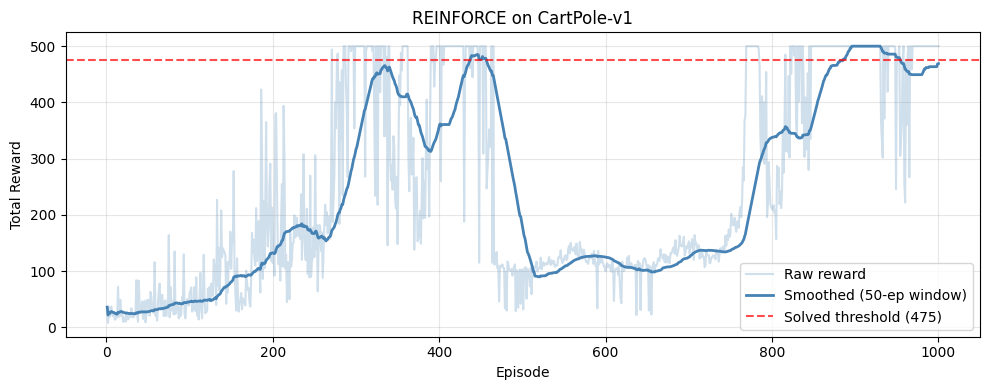

Saved → training_curve.png


In [7]:
def moving_average(values: list, window: int = 50) -> list:
    out = []
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        out.append(float(np.mean(values[lo : i + 1])))
    return out

fig, ax = plt.subplots(figsize=(10, 4))
eps = range(1, len(episode_rewards) + 1)

ax.plot(eps, episode_rewards, alpha=0.25, color="steelblue", label="Raw reward")
ax.plot(eps, moving_average(episode_rewards, 50), color="steelblue",
        linewidth=2, label="Smoothed (50-ep window)")
ax.axhline(475, color="red", linestyle="--", alpha=0.7, label="Solved threshold (475)")

ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.set_title("REINFORCE on CartPole-v1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=120)
plt.show()
print("Saved → training_curve.png")


## Record Trained Agent

In [8]:
def record_gif(
    policy: PolicyNetwork,
    filename: str = "agent.gif",
    max_steps: int = 500,
) -> str:
    """Run one greedy episode and save frames as an animated GIF."""
    env_rec = gym.make("CartPole-v1", render_mode="rgb_array")
    frames, total_reward = [], 0

    state, _ = env_rec.reset()
    done = False

    policy.eval()
    with torch.no_grad():
        while not done and len(frames) < max_steps:
            frames.append(env_rec.render())           # (H, W, 3) uint8
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
            action = policy(state_t).argmax().item()  # greedy
            state, reward, terminated, truncated, _ = env_rec.step(action)
            done = terminated or truncated
            total_reward += reward

    env_rec.close()
    policy.train()

    frames_arr = np.stack(frames)                     # (N, H, W, 3)
    iio.imwrite(filename, frames_arr, plugin="pillow", loop=0, duration=33)
    print(f"Recorded {len(frames)} frames  |  total reward: {total_reward:.0f}")
    print(f"GIF saved → {filename}")
    return filename

gif_path = record_gif(policy)


Recorded 500 frames  |  total reward: 500
GIF saved → agent.gif


## Trained Agent

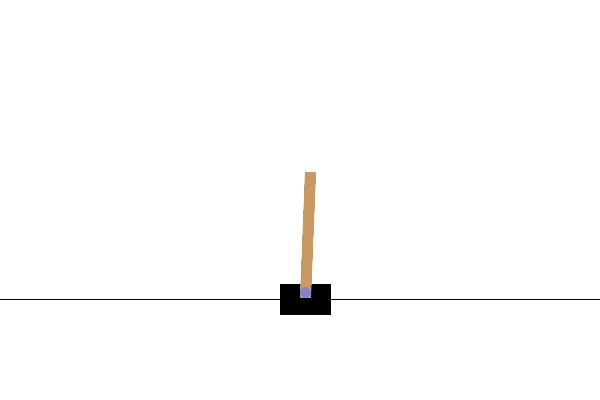

In [9]:
display(Image(gif_path))
